In [22]:
# imports
import numpy as np
from matplotlib import pyplot as plt
import h5py
from scipy.stats import sem, norm, pearsonr, ttest_1samp, wilcoxon, ttest_rel
import pickle

from functions import neuron_reliability, reliability_filtering_tb, check_normality

Figure 5 A

In [23]:
# define the exponential decay function 
def adapt_resp_decay(x, C, T):
    return C*np.exp(-x/T)

In [24]:
# load all the tau indices and define the plotting range - you can recompute the neural Tau values by running fig5_tau.ipynb
t_vals = np.load('data/tau_arr_s34_good_r2.npy')
x = np.arange(0,1000,10)

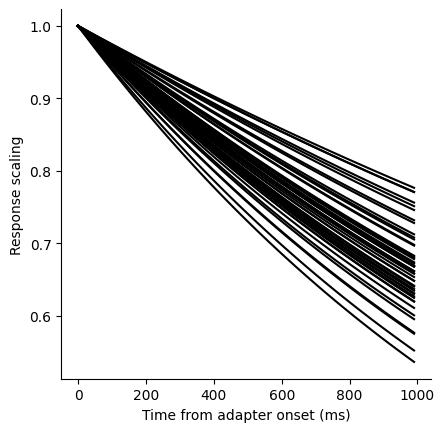

In [25]:
# plot the tau values for right and left motion adaptation
for i in range(t_vals.shape[0]):
    plt.plot(x,adapt_resp_decay(x,1,t_vals[i,0]),color='black')

plt.xlabel('Time from adapter onset (ms)')
plt.ylabel('Response scaling')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
x0, x1 = plt.gca().get_xlim()
y0, y1 = plt.gca().get_ylim()
plt.gca().set_aspect(abs(x1 - x0) / abs(y1 - y0)) 

# plt.savefig('/Users/lizayak/Capstone/neural_tau_ot.eps', format='eps', bbox_inches='tight')

Figure 5 B - run all cells for Figure 5 A before running these

In [26]:
# load the responses for S5 (no adaptation) - the aim is to use these to get reliable neurons for S5 during the tb from 70-170 ms
file_s5 = h5py.File('data/neural/230801.m1.rsvp.gratingsAdap_s5.experiment_psth_raw.h5','r')

rates_s5 = file_s5['/psth'][:]

s5_neural = np.transpose(np.nanmean(rates_s5[:,:,7:17,:],axis=2), (0,2,1))

/tmp/ipykernel_1079867/3337131199.py:6: RuntimeWarning: Mean of empty slice
  s5_neural = np.transpose(np.nanmean(rates_s5[:,:,7:17,:],axis=2), (0,2,1))


In [27]:
# get the array of neuron reliabilities during S5
rel = neuron_reliability(s5_neural)[0]

In [29]:
#load and format S3 (right motion adaptation) & S4 (left motion adaptation)
file_s3 = h5py.File('data/neural/230801.m1.rsvp.gratingsAdap_s3.experiment_psth_raw.h5','r')
file_s4 = h5py.File('data/neural/230801.m1.rsvp.gratingsAdap_s4.experiment_psth_raw.h5','r')

rates_s3 = file_s3['/psth'][:]
rates_s4 = file_s4['/psth'][:]

In [30]:
# get only the reliable neurons for S3 and S4
rates_s3 = reliability_filtering_tb(rates_s3, rel, metric=0.2)
rates_s4 = reliability_filtering_tb(rates_s4, rel, metric=0.2)

In [31]:
# get the neural data for fitting the decay function by averaging across images and selecting only 100-1100 ms and averaging across trials
neural_s3 = np.nanmean(np.nanmean(rates_s3[:,:,10:110,:], axis=0), axis=0)
neural_s4 = np.nanmean(np.nanmean(rates_s4[:,:,10:110,:], axis=0), axis=0)

neural_s3_se = sem(np.nanmean(rates_s3[:,:,10:110,:],axis=1), axis=0, nan_policy='omit')
neural_s4_se = sem(np.nanmean(rates_s4[:,:,10:110,:],axis=1), axis=0, nan_policy='omit')

In [32]:
# set up parameters
n_neurons = neural_s3.shape[1]
n_seasons = 2

In [33]:
# load the tau array - you can recompute the neural Tau values by running neural_tau.ipynb
tau_arr = np.load('data/tau_arr.npy')

In [34]:
# generate plotting data for each neuron and each season
tau_plts = np.empty((n_neurons, n_seasons, len(x)))
seasons = [neural_s3, neural_s4]
for s in range(n_seasons):
    season_data = seasons[s]
    for n in range(n_neurons):
        decay_res = adapt_resp_decay(x=x, C=tau_arr[n,s,1], T=tau_arr[n,s,0])
        tau_plts[n,s,:] = decay_res

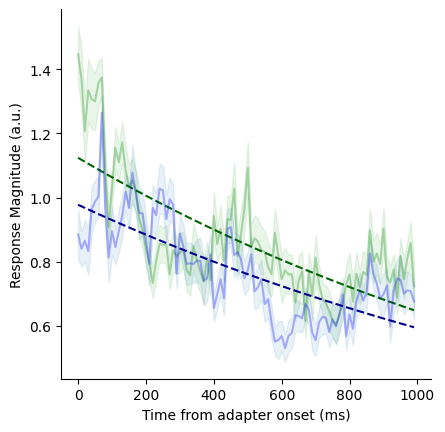

In [35]:
# plotting responses vs decay function fit for one example neuron
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.plot(x,neural_s3[:,67],color='green',alpha=0.3)
plt.fill_between(x, neural_s3[:,67]-neural_s3_se[:,67], neural_s3[:,67]+neural_s3_se[:,67], color='tab:green', alpha=0.1)
plt.plot(x,tau_plts[67,0,:], color='darkgreen',linestyle='--')

plt.plot(x,neural_s4[:,67],color='blue',alpha=0.3)
plt.fill_between(x, neural_s4[:,67]-neural_s4_se[:,67], neural_s4[:,67]+neural_s4_se[:,67], color='tab:blue', alpha=0.1)
plt.plot(x,tau_plts[67,1,:], color='darkblue',linestyle='--')

plt.xlabel('Time from adapter onset (ms)')
plt.ylabel('Response Magnitude (a.u.)')

x0,x1 = plt.gca().get_xlim()
y0,y1 = plt.gca().get_ylim()

plt.gca().set_aspect(abs(x1-x0)/abs(y1-y0))

# plt.savefig('unit67.eps', format='eps', bbox_inches='tight')

In [36]:
# print the tau values that define the plotted line
print('right adapt Tau for model unit:',tau_arr[67,0,0])
print('left adapt Tau for model unit:',tau_arr[67,1,0])

right adapt Tau for model unit: 1798.3584006095482
left adapt Tau for model unit: 1993.9750407387028


In [37]:
# get the values for the smoothed tau distribution
x_s3_dist = np.linspace(np.mean(t_vals[:,0]) - 2*np.std(t_vals[:,0]), np.mean(t_vals[:,0]) + 2*np.std(t_vals[:,0]), 1000)
x_s4_dist = np.linspace(np.mean(t_vals[:,1]) - 2*np.std(t_vals[:,1]), np.mean(t_vals[:,1]) + 2*np.std(t_vals[:,1]), 1000)

s3_pdf = norm.pdf(x_s3_dist, np.mean(t_vals[:,0]), np.std(t_vals[:,0]))
s4_pdf = norm.pdf(x_s3_dist, np.mean(t_vals[:,1]), np.std(t_vals[:,1]))

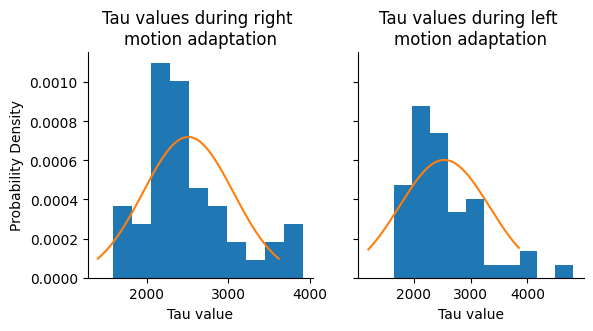

In [38]:
# plot the distribution of the tau values - raw and smoothed 
fig1,axs1=plt.subplots(1,2,sharey=True)

axs1[0].hist(t_vals[:,0],density=True)
axs1[0].plot(x_s3_dist,s3_pdf)
axs1[0].set(title='Tau values during right \nmotion adaptation')

axs1[1].hist(t_vals[:,1],density=True)
axs1[1].plot(x_s4_dist,s4_pdf)
axs1[1].set(title='Tau values during left \nmotion adaptation')

for n in range(2):
    axs1[n].spines['top'].set_visible(False)
    axs1[n].spines['right'].set_visible(False)
    axs1[n].set(ylabel='Probability Density',xlabel='Tau value')
    axs1[n].label_outer()
    # axs2[n].legend()
    x0, x1 = axs1[n].get_xlim()
    y0, y1 = axs1[n].get_ylim()
    axs1[n].set_aspect(abs(x1 - x0) / abs(y1 - y0)) 

# plt.savefig('/Users/lizayak/Capstone/neural_tau_dist.eps', format='eps', bbox_inches='tight')

Figure 5 C

In [2]:
# load the responses and predictions from the models  - to recreate these, run fig5_adapt_preds.sh

# alexnet 
alexnet_s3adapt_xpreds = np.load('data/alexnet_s3adapt_xpos_preds_ecc.npy')
alexnet_s3adapt_ypreds = np.load('data/alexnet_s3adapt_ypos_preds_ecc.npy')
alexnet_s4adapt_xpreds = np.load('data/alexnet_s4adapt_xpos_preds_ecc.npy')
alexnet_s4adapt_ypreds = np.load('data/alexnet_s4adapt_ypos_preds_ecc.npy')

# resnet18
resnet18_s3adapt_xpreds = np.load('data/resnet18_s3adapt_xpos_preds_ecc.npy')
resnet18_s3adapt_ypreds = np.load('data/resnet18_s3adapt_ypos_preds_ecc.npy')
resnet18_s4adapt_xpreds = np.load('data/resnet18_s4adapt_xpos_preds_ecc.npy')
resnet18_s4adapt_ypreds = np.load('data/resnet18_s4adapt_ypos_preds_ecc.npy')

# simclr_resnet50
simclr_resnet50_s3adapt_xpreds = np.load('data/simclr_resnet50_s3adapt_xpos_preds_ecc.npy')
simclr_resnet50_s3adapt_ypreds = np.load('data/simclr_resnet50_s3adapt_ypos_preds_ecc.npy')
simclr_resnet50_s4adapt_xpreds = np.load('data/simclr_resnet50_s4adapt_xpos_preds_ecc.npy')
simclr_resnet50_s4adapt_ypreds = np.load('data/simclr_resnet50_s4adapt_ypos_preds_ecc.npy')

# vgg16
vgg16_s3adapt_xpreds = np.load('data/vgg16_s3adapt_xpos_preds_ecc.npy')
vgg16_s3adapt_ypreds = np.load('data/vgg16_s3adapt_ypos_preds_ecc.npy')
vgg16_s4adapt_xpreds = np.load('data/vgg16_s4adapt_xpos_preds_ecc.npy')
vgg16_s4adapt_ypreds = np.load('data/vgg16_s4adapt_ypos_preds_ecc.npy')

# vitl32
vitl32_s3adapt_xpreds = np.load('data/vitl32_s3adapt_xpos_preds_ecc.npy')
vitl32_s3adapt_ypreds = np.load('data/vitl32_s3adapt_ypos_preds_ecc.npy')
vitl32_s4adapt_xpreds = np.load('data/vitl32_s4adapt_xpos_preds_ecc.npy')
vitl32_s4adapt_ypreds = np.load('data/vitl32_s4adapt_ypos_preds_ecc.npy')

In [3]:
# for all the plots that need time - 60 time points
times = np.arange(0,3050,50)
labels = ['alexnet', 'resnet18', 'vgg16', 'vitl32', 'simclr_resnet50']

In [4]:
# load the s5 xpos and ypos preds for the models - to get a good comparison with what is going on with human data
# to recreate these, run fig5_preds.sh
alexnet_s5_xpreds = np.load('data/alexnet_s5_xpos_preds_ecc.npy')
alexnet_s5_ypreds = np.load('data/alexnet_s5_ypos_preds_ecc.npy')

resnet18_s5_xpreds = np.load('data/resnet18_s5_xpos_preds_ecc.npy')
resnet18_s5_ypreds = np.load('data/resnet18_s5_ypos_preds_ecc.npy')

vgg16_s5_xpreds = np.load('data/vgg16_s5_xpos_preds_ecc.npy')
vgg16_s5_ypreds = np.load('data/vgg16_s5_ypos_preds_ecc.npy')

vitl32_s5_xpreds = np.load('data/vitl32_s5_xpos_preds_ecc.npy')
vitl32_s5_ypreds = np.load('data/vitl32_s5_ypos_preds_ecc.npy')

simclr_resnet50_s5_xpreds = np.load('data/simclr_resnet50_s5_xpos_preds_ecc.npy')
simclr_resnet50_s5_ypreds = np.load('data/simclr_resnet50_s5_ypos_preds_ecc.npy')

In [5]:
# across all reps  
def get_ot_corrs(preds,s5_preds,n_reps=100, one_time=False, focus_time=None):
    corrs = np.empty((100,61)) # number of reps we want to look at
    use_preds = np.nanmean(preds,axis=3)
    if one_time == True:
        corrs = np.empty(100)
        for r in range(n_reps):
            corrs[r] = pearsonr(np.squeeze(s5_preds[:,r]), np.squeeze(use_preds[:,r,focus_time]))[0]
        return np.nanmean(corrs)
    else:
        for t in range(61):
            for r in range(n_reps):
                corrs[r,t] = pearsonr(np.squeeze(s5_preds[:,r]), np.squeeze(use_preds[:,r,t]))[0]
        return np.nanmean(corrs,axis=0), np.nanstd(corrs,axis=0)

In [6]:
# get the changes in correlation across time
s5_xpos_preds = [alexnet_s5_xpreds, resnet18_s5_xpreds, vgg16_s5_xpreds, vitl32_s5_xpreds, simclr_resnet50_s5_xpreds]
s5_ypos_preds = [alexnet_s5_ypreds, resnet18_s5_ypreds, vgg16_s5_ypreds, vitl32_s5_ypreds, simclr_resnet50_s5_ypreds]
s3_xpos_preds = [alexnet_s3adapt_xpreds,resnet18_s3adapt_xpreds,vgg16_s3adapt_xpreds,vitl32_s3adapt_xpreds,simclr_resnet50_s3adapt_xpreds]
s3_ypos_preds = [alexnet_s3adapt_ypreds,resnet18_s3adapt_ypreds,vgg16_s3adapt_ypreds,vitl32_s3adapt_ypreds,simclr_resnet50_s3adapt_ypreds]
s4_xpos_preds = [alexnet_s4adapt_xpreds,resnet18_s4adapt_xpreds,vgg16_s4adapt_xpreds,vitl32_s4adapt_xpreds,simclr_resnet50_s4adapt_xpreds]
s4_ypos_preds = [alexnet_s4adapt_ypreds,resnet18_s4adapt_ypreds,vgg16_s4adapt_ypreds,vitl32_s4adapt_ypreds,simclr_resnet50_s4adapt_ypreds]

x_corrs_s3_adpat = []
x_corrs_stds_s3_adapt = []
y_corrs_s3_adapt = []
y_corrs_stds_s3_adapt = []

x_corrs_s4_adapt=[]
x_corrs_stds_s4_adapt = []
y_corrs_s4_adapt = []
y_corrs_stds_s4_adapt = []

# dict for storing all the ot corrs for the bar plot 
s3_corrs_dict = {}
s4_corrs_dict = {}
models = ['alexnet', 'resnet18', 'vgg16', 'vitl32', 'simclr_resnet50']

for i in range(5):
    s3_xcorrs, s3_xstds = get_ot_corrs(s3_xpos_preds[i],s5_xpos_preds[i])
    x_corrs_s3_adpat.append(s3_xcorrs[-1])
    x_corrs_stds_s3_adapt.append(s3_xstds[-1])
    s3_corrs_dict[models[i]] = s3_xcorrs

    s3_ycorrs, s3_ystds = get_ot_corrs(s3_ypos_preds[i],s5_ypos_preds[i])
    y_corrs_s3_adapt.append(s3_ycorrs[-1])
    y_corrs_stds_s3_adapt.append(s3_ystds[-1])

    s4_xcorrs, s4_xstds = get_ot_corrs(s4_xpos_preds[i],s5_xpos_preds[i])
    x_corrs_s4_adapt.append(s4_xcorrs[-1])
    x_corrs_stds_s4_adapt.append(s4_xstds[-1])
    s4_corrs_dict[models[i]] = s4_xcorrs

    s4_ycorrs, s4_ystds = get_ot_corrs(s4_ypos_preds[i],s5_ypos_preds[i])
    y_corrs_s4_adapt.append(s4_ycorrs[-1])
    y_corrs_stds_s4_adapt.append(s4_ystds[-1])

In [7]:
# get the average s3 and s4 x correlations throughout adaptation for all the models 
import pickle

all_s3_corrs = np.empty((5,61))
all_s4_corrs = np.empty((5,61))

zoo_models = ['alexnet', 'resnet18', 'vgg16', 'vitl32', 'simclr_resnet50']

for i in range(len(zoo_models)):
    all_s3_corrs[i,:] = s3_corrs_dict[zoo_models[i]]
    all_s4_corrs[i,:] = s4_corrs_dict[zoo_models[i]]

mean_s3_corr = np.nanmean(all_s3_corrs, axis=0)
err_s3_corr = sem(all_s3_corrs,axis=0)

mean_s4_corr = np.nanmean(all_s4_corrs,axis=0)
err_s4_corr = sem(all_s4_corrs, axis=0)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


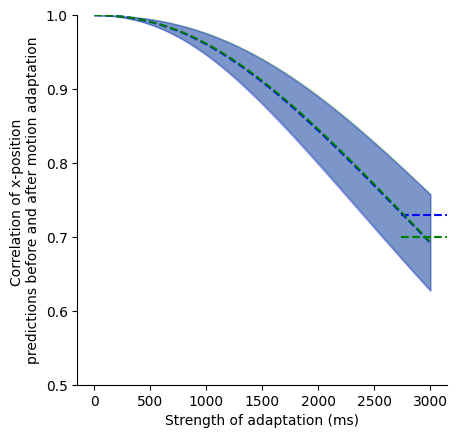

In [12]:
# plot these correlations for s3 and s4
fig,ax = plt.subplots()

ax.plot(times,mean_s3_corr,linestyle='--',zorder=3,color='green')
ax.fill_between(times,mean_s3_corr-err_s3_corr,mean_s3_corr+err_s3_corr,alpha=0.3,zorder=1,color='green')

ax.plot(times,mean_s4_corr,linestyle='--',color='blue')
ax.fill_between(times,mean_s4_corr-err_s4_corr,mean_s4_corr+err_s4_corr,alpha=0.3,color='blue')

ax.axhline(0.70,xmin=0.875,xmax=1,color='green',linestyle='--') # corresponding neural result following rightward motion adaptation

ax.axhline(0.73,xmin=0.875,xmax=1,color='blue',linestyle='--') # corresponding neural result following leftward motion adaptation

ax.set(xlabel='Strength of adaptation (ms)',ylabel='Correlation of x-position \npredictions before and after motion adaptation')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0.5,1)
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()
ax.set_aspect(abs(x1 - x0) / abs(y1 - y0)) 

plt.savefig('/home/eyakub/scratch/adapted_zoo_xcorrs.eps', format='eps', bbox_inches='tight')

In [13]:
# get all the correlations you need to do the t-test - slightly different format, which is why we are redoing it
s3_xpos_preds = [alexnet_s3adapt_xpreds,resnet18_s3adapt_xpreds,vgg16_s3adapt_xpreds,vitl32_s3adapt_xpreds,simclr_resnet50_s3adapt_xpreds]
s4_xpos_preds = [alexnet_s4adapt_xpreds,resnet18_s4adapt_xpreds,vgg16_s4adapt_xpreds,vitl32_s4adapt_xpreds,simclr_resnet50_s4adapt_xpreds]

s5_xpos_preds = [alexnet_s5_xpreds, resnet18_s5_xpreds, vgg16_s5_xpreds, vitl32_s5_xpreds, simclr_resnet50_s5_xpreds]

s3_corrs_array = np.empty(5)
s4_corrs_array = np.empty(5)

for i in range(5):
    s3_xcorrs = get_ot_corrs(s3_xpos_preds[i],s5_xpos_preds[i],one_time=True,focus_time=-1)
    s3_corrs_array[i] = s3_xcorrs

    s4_xcorrs = get_ot_corrs(s4_xpos_preds[i],s5_xpos_preds[i],one_time=True,focus_time=-1)
    s4_corrs_array[i] = s4_xcorrs

In [14]:
# check whether model stats are normally distributed - yes, so can do single t, no problenm
p_s3 = check_normality('singlet', s3_corrs_array)
print('s3:', p_s3)

p_s4 = check_normality('singlet', s4_corrs_array)
print('s4:', p_s4)

s3: 0.6647884249687195
s4: 0.6713141798973083


In [16]:
# do the t-test 
# load the values you need 
neural_s3x_corrs = np.nanmean(np.load('data/s3xpreds_s5_corr.npy'))
neural_s4x_corrs = np.nanmean(np.load('data/s4xpreds_s5_corr.npy'))

# run the ttest
print(f'ttest of R(s3model_preds,s5) and R(s3neural_preds,s5): {ttest_1samp(s3_corrs_array,neural_s3x_corrs)}')
print(f'ttest of R(s4model_preds,s5) and R(s4neural_preds,s5): {ttest_1samp(s4_corrs_array,neural_s4x_corrs)}')

ttest of R(s3model_preds,s5) and R(s3neural_preds,s5): TtestResult(statistic=-0.17005421764114317, pvalue=0.8732219396435192, df=4)
ttest of R(s4model_preds,s5) and R(s4neural_preds,s5): TtestResult(statistic=-0.5400302904672981, pvalue=0.6178378589728818, df=4)


Figure 5 D - ensure you run the cells for Figure 5 C beforehand

In [16]:
# load the human deltas
import pickle
with open('data/human_deltax_dict.pkl', 'rb') as f:
    human_deltax = pickle.load(f)['s4_v_s3']

In [20]:
# load the neural deltas 
neural_deltax = np.load('data/pixel_space_neurals34_deltax.npy') 

In [24]:
# define the function to look at deltas over strength of adaptation
def deltas_ot(model,s3adapt_xpreds,s3adapt_ypreds,s4adapt_xpreds,s4adapt_ypreds,s5_xpreds,s5_ypreds,n_repsx,n_repsy):
    s5_xpreds = np.nanmean(s5_xpreds[:,:n_repsx],axis=1)
    s5_ypreds = np.nanmean(s5_ypreds[:,:n_repsy],axis=1)

    s3_xpreds = np.nanmean(np.nanmean(s3adapt_xpreds[:,:n_repsx,:,:],axis=3),axis=1) # images x reps x time x iterations

    s3_ypreds = np.nanmean(np.nanmean(s3adapt_ypreds[:,:n_repsy,:,:],axis=3),axis=1)

    s4_xpreds = np.nanmean(np.nanmean(s4adapt_xpreds[:,:n_repsx,:,:],axis=3),axis=1)

    s4_ypreds = np.nanmean(np.nanmean(s4adapt_ypreds[:,:n_repsy,:,:],axis=3),axis=1)

    avg_deltax = np.nanmean(s4_xpreds - s3_xpreds, axis=0) # average delta for each time point
    avg_deltax_sem = sem(s4_xpreds - s3_xpreds, axis=0) # standard error of the mean of the delta across images 

    avg_deltay = np.nanmean(s4_ypreds - s3_ypreds, axis=0)
    avg_deltay_sem = sem(s4_ypreds - s3_ypreds, axis=0) # standard error of the mean of the delta across images

    delta_dict={'avg_deltax':avg_deltax,'avg_deltax_sem':avg_deltax_sem,'avg_deltay':avg_deltay,'avg_deltay_sem':avg_deltay_sem}

    # plot the deltas across adaptation strength
    fig,axs = plt.subplots(1,2,sharey=True)

    fig.suptitle(f'Bias in x and y position decodes from {model} features following adaptation')

    axs[0].errorbar(times,avg_deltax,yerr=avg_deltax_sem,fmt='o',color='darkslateblue',zorder=1)
    axs[0].set(ylabel='Average Delta X-Position (left-right)', xlabel='Strength of adaptation (ms)')

    axs[1].errorbar(times,avg_deltay,yerr=avg_deltay_sem,fmt='o',color='lightsteelblue',zorder=1)
    axs[1].set(ylabel='Average Delta Y-Position (left-right)', xlabel='Strength of adaptation (ms)')

    for n in range(2):
        axs[n].spines['top'].set_visible(False)
        axs[n].spines['right'].set_visible(False)
        x0, x1 = axs[n].get_xlim()
        y0, y1 = axs[n].get_ylim()
        axs[n].set_aspect(abs(x1 - x0) / abs(y1 - y0))  
    
    return delta_dict

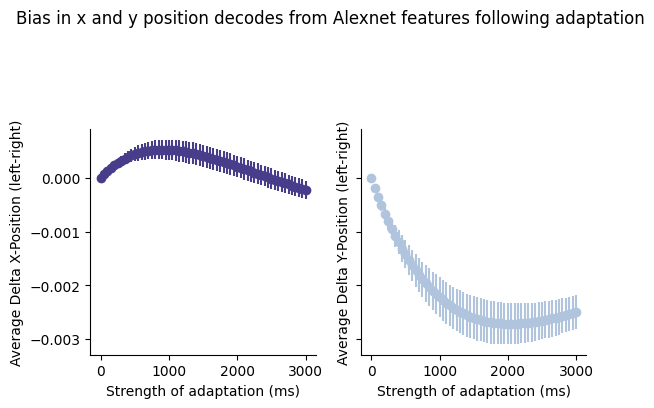

In [25]:
# alexnet deltas 
alexnet_deltas = deltas_ot(
    'Alexnet',
    alexnet_s3adapt_xpreds,
    alexnet_s3adapt_ypreds,
    alexnet_s4adapt_xpreds,
    alexnet_s4adapt_ypreds,
    alexnet_s5_xpreds,
    alexnet_s5_ypreds,
    100,
    100
)

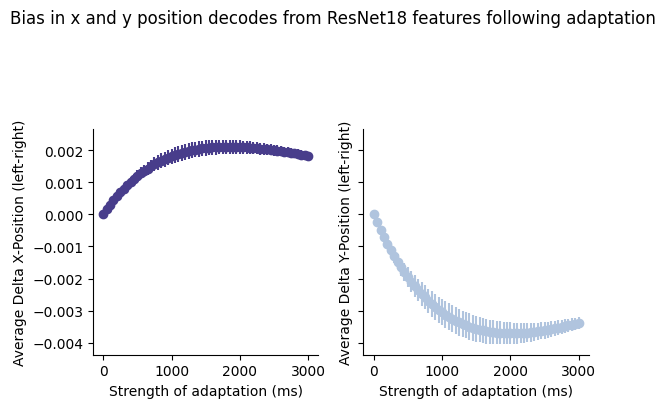

In [26]:
# resnet18 deltas
resnet18_deltas = deltas_ot(
    'ResNet18',
    resnet18_s3adapt_xpreds,
    resnet18_s3adapt_ypreds,
    resnet18_s4adapt_xpreds,
    resnet18_s4adapt_ypreds,
    resnet18_s5_xpreds,
    resnet18_s5_ypreds,
    100,
    100
)

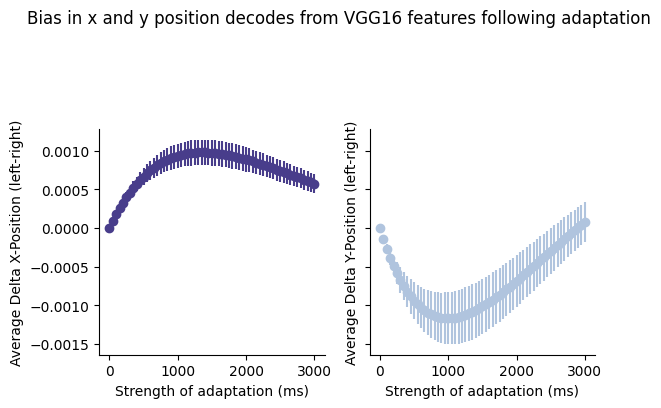

In [27]:
# vgg16 deltas 
vgg16_deltas = deltas_ot(
    'VGG16',
    vgg16_s3adapt_xpreds,
    vgg16_s3adapt_ypreds,
    vgg16_s4adapt_xpreds,
    vgg16_s4adapt_ypreds,
    vgg16_s5_xpreds,
    vgg16_s5_ypreds,
    100,
    100
)

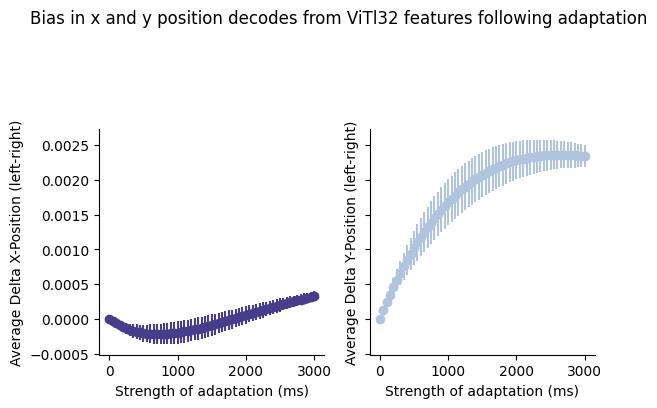

In [28]:
# vitl32 deltas 
vitl32_deltas = deltas_ot(
    'ViTl32',
    vitl32_s3adapt_xpreds,
    vitl32_s3adapt_ypreds,
    vitl32_s4adapt_xpreds,
    vitl32_s4adapt_ypreds,
    vitl32_s5_xpreds,
    vitl32_s5_ypreds,
    100,
    100
)

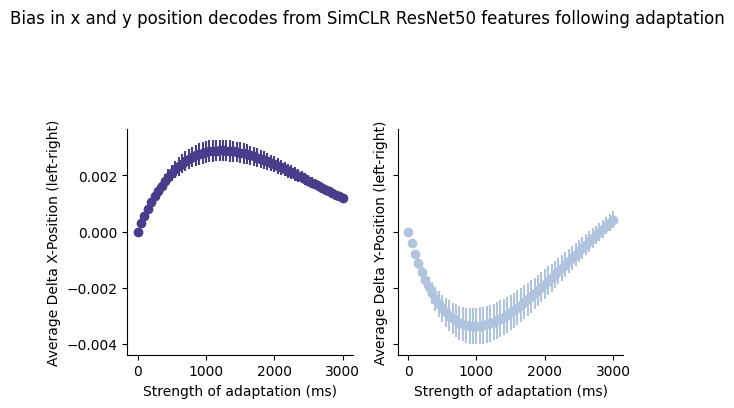

In [29]:
# simclr_resnet50 deltas
simclr_resnet50_deltas = deltas_ot(
    'SimCLR ResNet50',
    simclr_resnet50_s3adapt_xpreds,
    simclr_resnet50_s3adapt_ypreds,
    simclr_resnet50_s4adapt_xpreds,
    simclr_resnet50_s4adapt_ypreds,
    simclr_resnet50_s5_xpreds,
    simclr_resnet50_s5_ypreds,
    100,
    100
)

In [35]:
# load slowfast and convrnn deltas - to recreate these results, run fig5_slowfast.ipynb and fig5_convrnn.ipynb
slowfast_deltax = np.load('data/slowfastx_nonadapt_delta.npy')
convrnn_deltax = np.load('data/convrnn_deltax.npy')

In [36]:
# for each model, get deltas for the last timepoint and perform the test

# load the data if you don't already have it
s3_xpos_preds = [alexnet_s3adapt_xpreds,resnet18_s3adapt_xpreds,vgg16_s3adapt_xpreds,vitl32_s3adapt_xpreds,simclr_resnet50_s3adapt_xpreds]
s4_xpos_preds = [alexnet_s4adapt_xpreds,resnet18_s4adapt_xpreds,vgg16_s4adapt_xpreds,vitl32_s4adapt_xpreds,simclr_resnet50_s4adapt_xpreds]
models = ['alexnet', 'resnet18', 'vgg16', 'vitl32', 'simclr_resnet50', 'slowfast', 'convrnn']
existing_deltas = [slowfast_deltax,convrnn_deltax]

# set up the dictionary for easy visualization
data_dict = {}
data_dict['model'] = models
data_dict['delta'] = []
data_dict['delta_std'] = []
data_dict['h_test'] = []
data_dict['human_comp'] = []
data_dict['n_test'] = []
data_dict['nhp_comp'] = []

# loop through the models, compute deltas and do test 
for i in range(len(models)):

    if i < 5:
        # get deltas
        tmp_s3 = np.squeeze(np.nanmean(np.nanmean(s3_xpos_preds[i][:,:,-1,:],axis=-1),axis=1))
        tmp_s4 = np.squeeze(np.nanmean(np.nanmean(s4_xpos_preds[i][:,:,-1,:],axis=-1),axis=1))
        tmp_model_deltas = tmp_s4-tmp_s3

    else:
        # get the deltas from SlowFast and ConvRNN
        tmp_model_deltas = existing_deltas[int(i-5)] 

    data_dict['delta'].append(np.nanmean(tmp_model_deltas))
    data_dict['delta_std'].append(np.nanstd(tmp_model_deltas))

    # compare to human 

    # first check that differences are normal
    p_val = check_normality('pairedt', tmp_model_deltas, human_deltax)

    # make appropriate test
    if p_val <= 0.05:
        data_dict['h_test'].append('wilcoxon')
        data_dict['human_comp'].append(wilcoxon(tmp_model_deltas, human_deltax))
    else:
        data_dict['h_test'].append('ttest')
        data_dict['human_comp'].append(ttest_rel(tmp_model_deltas, human_deltax))

    # compare to nhp 

    # check that differences are normal
    p_val = check_normality('pairedt', tmp_model_deltas, neural_deltax)

    # make appropriate test
    if p_val <= 0.05:
        data_dict['n_test'].append('wilcoxon')
        data_dict['nhp_comp'].append(wilcoxon(tmp_model_deltas, neural_deltax))
    else:
        data_dict['n_test'].append('ttest')
        data_dict['nhp_comp'].append(ttest_rel(tmp_model_deltas, neural_deltax))

In [37]:
# visualize results as dataframe
import pandas as pd
df = pd.DataFrame(data_dict)
df

,model,delta,delta_std,h_test,human_comp,n_test,nhp_comp
0,alexnet,-0.000223,0.001098,ttest,"(-8.806472190761497, 8.229785966664068e-11)",ttest,"(-6.247348945093255, 2.348286831993279e-07)"
1,resnet18,0.001827,0.000802,ttest,"(-8.750851591476463, 9.716352941508964e-11)",ttest,"(-6.233218631341561, 2.4567549634116627e-07)"
2,vgg16,0.000575,0.000767,ttest,"(-8.785576292061505, 8.759155433117217e-11)",ttest,"(-6.240971466536465, 2.396634810235727e-07)"
3,vitl32,0.000325,0.000450,ttest,"(-8.787186336105133, 8.717167250490753e-11)",ttest,"(-6.242910896782196, 2.3818272684638456e-07)"
4,simclr_resnet50,0.001191,0.000748,ttest,"(-8.76610695417411, 9.283420319451212e-11)",ttest,"(-6.237173439828075, 2.425900501135149e-07)"
5,slowfast,0.019006,0.023877,ttest,"(-8.363691880246922, 3.1177418260186804e-10)",ttest,"(-6.072630747871578, 4.1052822158272443e-07)"
6,convrnn,-0.001608,0.004998,ttest,"(-8.81213565491164, 8.091976402152453e-11)",ttest,"(-6.250564580349783, 2.3242808682288273e-07)"


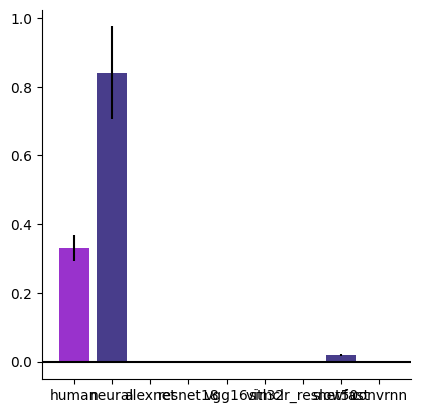

In [39]:
# plot the last adapted model delta against the human and nhp 
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

models = ['human', 'neural', 'alexnet', 'resnet18', 'vgg16', 'vitl32', 'simclr_resnet50', 'slowfast', 'convrnn']
colors = ['darkorchid','darkslateblue','darkslateblue','darkslateblue','darkslateblue','darkslateblue','darkslateblue', 'darkslateblue', 'darkslateblue']
deltas = [np.nanmean(human_deltax),np.nanmean(neural_deltax),alexnet_deltas['avg_deltax'][-1],resnet18_deltas['avg_deltax'][-1],vgg16_deltas['avg_deltax'][-1],vitl32_deltas['avg_deltax'][-1],simclr_resnet50_deltas['avg_deltax'][-1],np.nanmean(slowfast_deltax),np.nanmean(convrnn_deltax)]
sems = [sem(human_deltax),sem(neural_deltax),alexnet_deltas['avg_deltax_sem'][-1],resnet18_deltas['avg_deltax_sem'][-1],vgg16_deltas['avg_deltax_sem'][-1],vitl32_deltas['avg_deltax'][-1],simclr_resnet50_deltas['avg_deltax_sem'][-1],sem(slowfast_deltax),sem(convrnn_deltax)]

plt.bar(models,deltas,yerr=sems,color=colors)
plt.axhline(0,color='black')

x0,x1 = plt.gca().get_xlim()
y0,y1 = plt.gca().get_ylim()

plt.gca().set_aspect(abs(x1-x0)/abs(y1-y0))

# plt.savefig('/home/eyakub/scratch/allx_deltas.eps', format='eps', bbox_inches='tight')